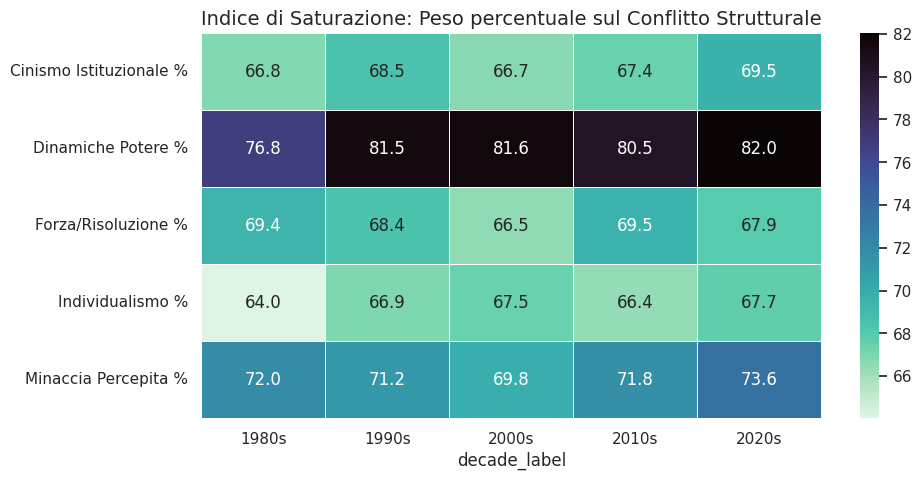

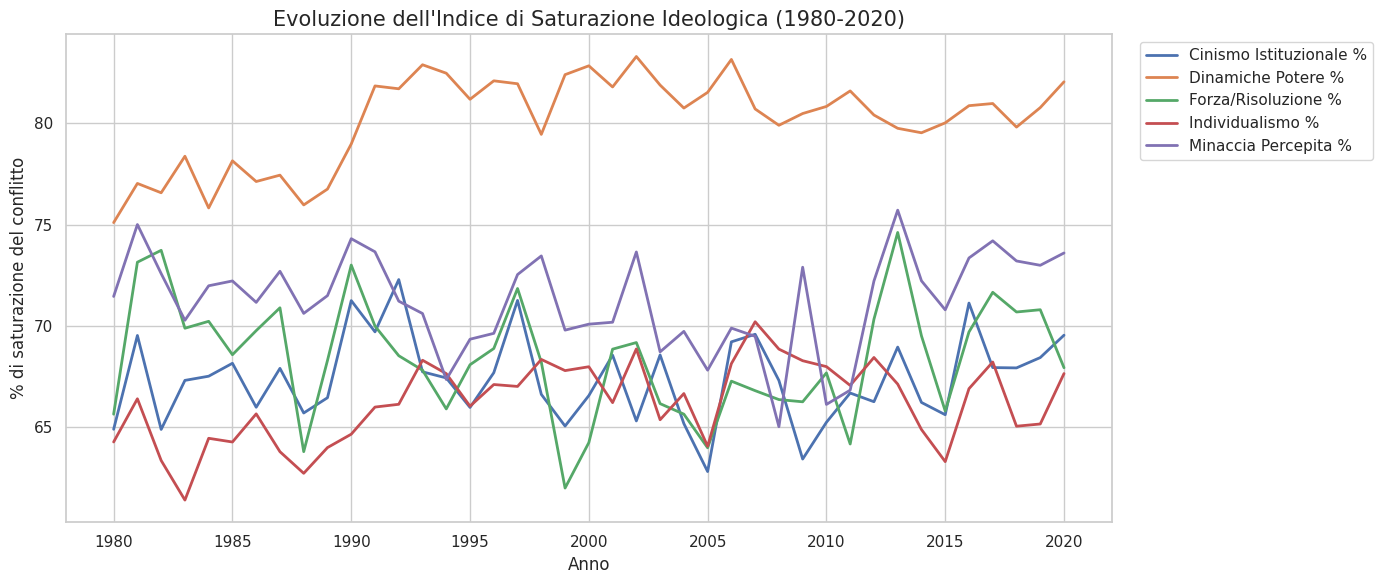

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Caricamento Dati
df_meta = pd.read_csv('/work/data/metadata/metadata_final.csv')
df_meta['decade'] = (df_meta['box_office_year'] // 10) * 10
df_meta['decade_label'] = df_meta['decade'].astype(str) + "s"
df_llm = pd.read_csv('/work/llm_outputs/DATABASE_TESI_COMPLETO.csv') 
df_full = pd.merge(df_meta, df_llm, on='imdb_id', how='inner')

# 2. Calcolo Indice di Saturazione Ideologica (Percentuale)
temi_ideologici = {
    'force_as_resolution': 'Forza/Risoluzione %', 
    'institutional_cynicism': 'Cinismo Istituzionale %', 
    'power_dynamics': 'Dinamiche Potere %', 
    'extreme_individualism': 'Individualismo %', 
    'perceived_threat': 'Minaccia Percepita %'
}

dati_relativi = []
for _, row in df_full.iterrows():
    conflitto_strutturale = row.get('structural_conflict_score')
    # Evitiamo divisioni per zero o conflitti nulli
    if pd.notna(conflitto_strutturale) and conflitto_strutturale > 0:
        for tema, label in temi_ideologici.items():
            score_col = f"{tema}_score"
            if pd.notna(row.get(score_col)):
                # FORMULA MAGICA: (Tema / Conflitto) * 100
                percentuale = (float(row[score_col]) / float(conflitto_strutturale)) * 100
                dati_relativi.append({
                    'box_office_year': row['box_office_year'],
                    'decade_label': row['decade_label'],
                    'Tema Relativo': label,
                    'Saturazione (%)': percentuale
                })
df_relativo = pd.DataFrame(dati_relativi)

# --- GRAFICO 1: Heatmap Relativa (Il peso sul conflitto) ---
heatmap_relativa = df_relativo.pivot_table(index='Tema Relativo', columns='decade_label', values='Saturazione (%)', aggfunc='mean')
plt.figure(figsize=(10, 5))
sns.heatmap(heatmap_relativa, annot=True, cmap="mako_r", fmt=".1f", linewidths=.5)
plt.title('Indice di Saturazione: Peso percentuale sul Conflitto Strutturale', fontsize=14)
plt.ylabel('')
plt.show()

# --- GRAFICO 2: Line Chart delle Percentuali nel tempo ---
yearly_rel_data = df_relativo.groupby(['box_office_year', 'Tema Relativo'])['Saturazione (%)'].mean().reset_index()
plt.figure(figsize=(14, 6))
sns.lineplot(data=yearly_rel_data, x='box_office_year', y='Saturazione (%)', hue='Tema Relativo', linewidth=2)
plt.title('Evoluzione dell\'Indice di Saturazione Ideologica (1980-2020)', fontsize=15)
plt.ylabel('% di saturazione del conflitto')
plt.xlabel('Anno')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setup estetico per grafici da Tesi
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'sans-serif'

In [3]:
# 1. Caricamento Metadati
df_meta = pd.read_csv('/work/data/metadata/metadata_final.csv')
df_meta['decade'] = (df_meta['box_office_year'] // 10) * 10
df_meta['decade_label'] = df_meta['decade'].astype(str) + "s"

# 2. Caricamento Risultati LLM (rimozione duplicati pre-merge)
df_llm = pd.read_csv('/work/llm_outputs/DATABASE_TESI_COMPLETO.csv') 
df_llm = df_llm.drop(columns=['title', 'domestic_box_office_gross'], errors='ignore')

# Merge
df_full = pd.merge(df_meta, df_llm, on='imdb_id', how='inner')
print(f"Dataset unito con successo. Totale film analizzati: {len(df_full)}")

Dataset unito con successo. Totale film analizzati: 4100


In [4]:
# Definiamo i temi ideologici da convertire in percentuale
temi_ideologici = {
    'force_as_resolution_score': 'Forza/Risoluzione %', 
    'institutional_cynicism_score': 'Cinismo Istituzionale %', 
    'power_dynamics_score': 'Dinamiche Potere %', 
    'extreme_individualism_score': 'Individualismo Estremo %', 
    'perceived_threat_score': 'Minaccia Percepita %'
}

dati_relativi = []

for _, row in df_full.iterrows():
    # Estraiamo il Conflitto Strutturale che farà da denominatore
    conflitto = row.get('structural_conflict_score')
    
    # Procediamo solo se il conflitto esiste ed è maggiore di zero
    if pd.notna(conflitto) and float(conflitto) > 0:
        for col, label in temi_ideologici.items():
            if pd.notna(row.get(col)):
                
                # LA FORMULA DELLA SATURAZIONE: (Tema / Conflitto) * 100
                percentuale = (float(row[col]) / float(conflitto)) * 100
                
                # Limitiamo la percentuale a 100% nel caso improbabile in cui un tema superi il conflitto
                percentuale = min(percentuale, 100.0) 
                
                dati_relativi.append({
                    'imdb_id': row['imdb_id'],
                    'title': row['title'],
                    'box_office_year': row['box_office_year'],
                    'decade_label': row['decade_label'],
                    'genre': row['genre'],
                    'Tema Relativo': label,
                    'Saturazione (%)': percentuale
                })

df_relativo = pd.DataFrame(dati_relativi)
print(f"Dataset Relativo pronto: calcolate {len(df_relativo)} percentuali di saturazione.")

Dataset Relativo pronto: calcolate 20469 percentuali di saturazione.


Analisi 1 - Saturazione Globale Media (Barplot)

/tmp/ipykernel_506/3250305794.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


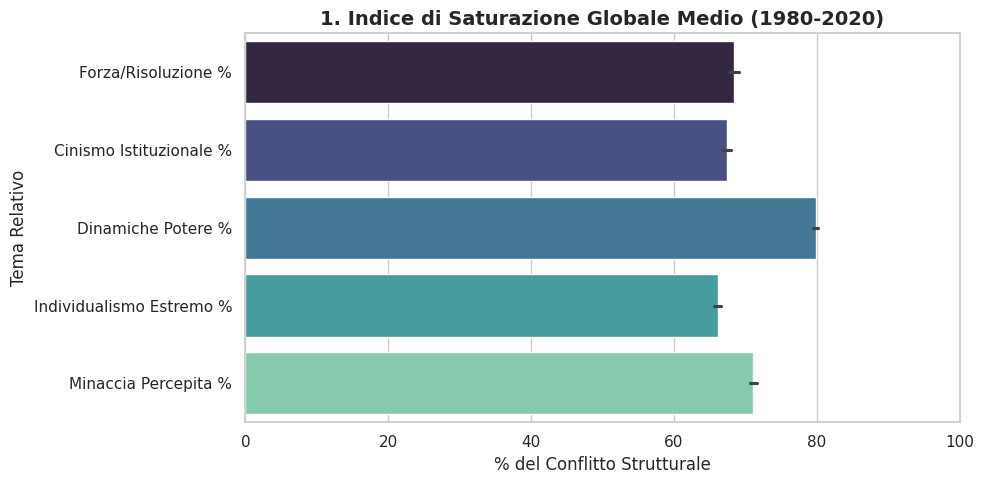

In [5]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=df_relativo, 
    x='Saturazione (%)', 
    y='Tema Relativo', 
    estimator=np.mean, 
    errorbar=('ci', 95), 
    palette="mako", 
    orient='h'
)
plt.title('1. Indice di Saturazione Globale Medio (1980-2020)', fontsize=14, fontweight='bold')
plt.xlim(0, 100)
plt.xlabel('% del Conflitto Strutturale')
plt.tight_layout()
plt.savefig('07B_plot1_saturazione_bar.png', dpi=300)
plt.show()

Analisi 2 - Heatmap Decennale delle Percentuali
Questo grafico è fondamentale per il capitolo 3.1.2. Mostra quanto "pesa" ciascun tema in ogni decennio.

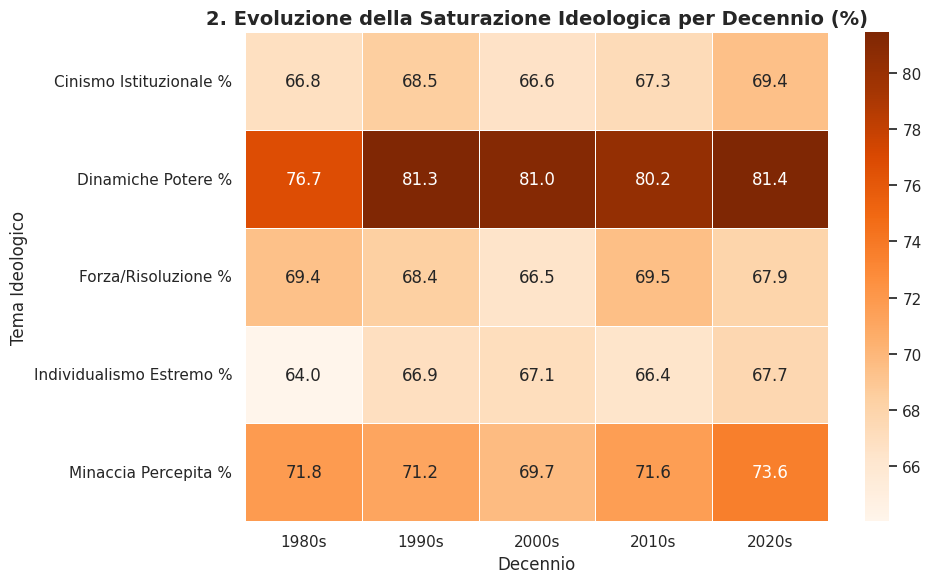

In [6]:
heatmap_relativa = df_relativo.pivot_table(
    index='Tema Relativo', 
    columns='decade_label', 
    values='Saturazione (%)', 
    aggfunc='mean'
)

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_relativa, annot=True, cmap="Oranges", fmt=".1f", linewidths=.5)
plt.title('2. Evoluzione della Saturazione Ideologica per Decennio (%)', fontsize=14, fontweight='bold')
plt.ylabel('Tema Ideologico')
plt.xlabel('Decennio')
plt.tight_layout()
plt.savefig('07B_plot2_heatmap_decenni.png', dpi=300)
plt.show()

Analisi 3 - Il Trend Lineare della Saturazione
Questa è la mappa sismica delle percentuali.

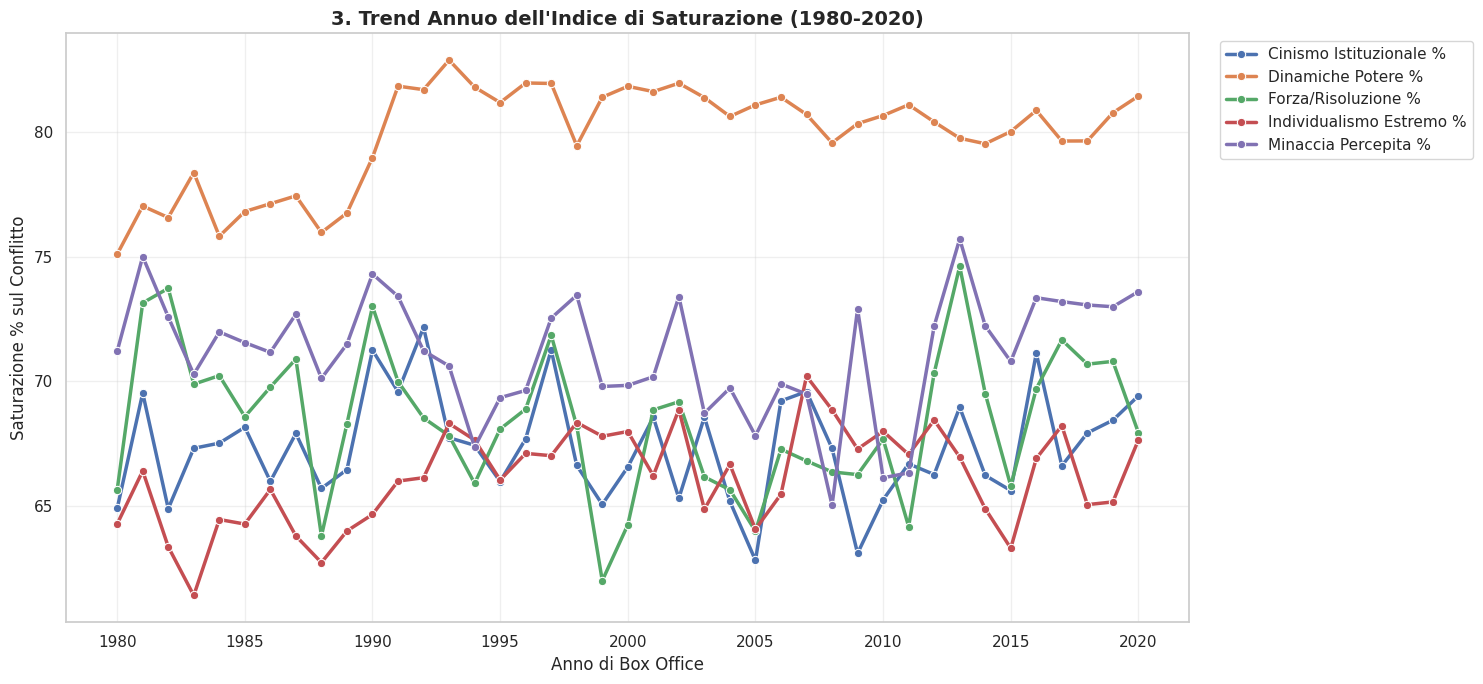

In [7]:
yearly_rel_data = df_relativo.groupby(['box_office_year', 'Tema Relativo'])['Saturazione (%)'].mean().reset_index()

plt.figure(figsize=(15, 7))
sns.lineplot(
    data=yearly_rel_data, 
    x='box_office_year', 
    y='Saturazione (%)', 
    hue='Tema Relativo', 
    linewidth=2.5, 
    marker='o'
)
plt.title('3. Trend Annuo dell\'Indice di Saturazione (1980-2020)', fontsize=14, fontweight='bold')
plt.ylabel('Saturazione % sul Conflitto')
plt.xlabel('Anno di Box Office')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('07B_plot3_line_trend.png', dpi=300)
plt.show()

Analisi 4 - Il Veicolo di Genere (Heatmap Relativa)
Risponde alla domanda: "In percentuale, l'Action è più saturato dalla Forza rispetto alla Commedia?"

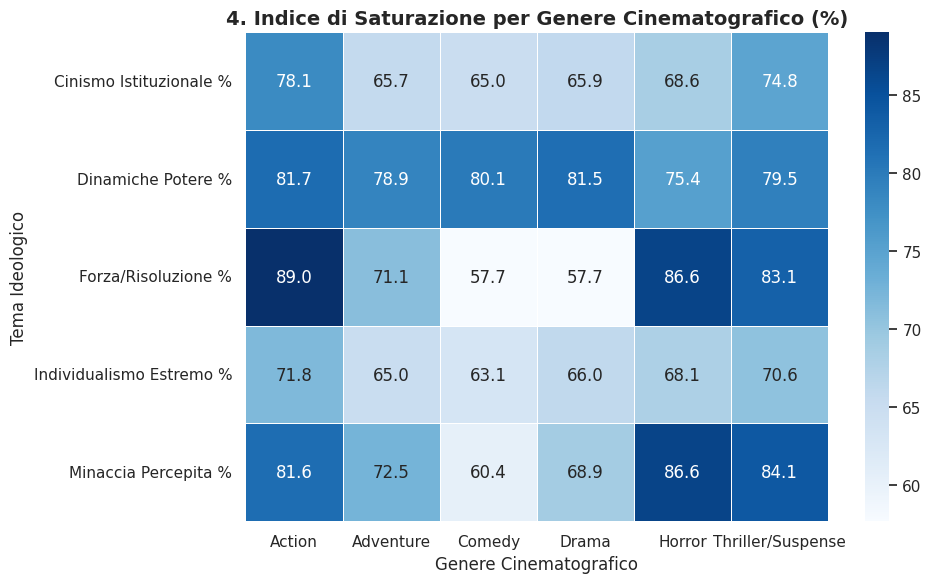

In [8]:
# Filtriamo i 6 generi più frequenti
generi_top_rel = df_relativo['genre'].value_counts().head(6).index
df_generi_rel = df_relativo[df_relativo['genre'].isin(generi_top_rel)]

heatmap_generi_rel = df_generi_rel.pivot_table(
    index='Tema Relativo', 
    columns='genre', 
    values='Saturazione (%)', 
    aggfunc='mean'
)

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_generi_rel, annot=True, cmap="Blues", fmt=".1f", linewidths=.5)
plt.title('4. Indice di Saturazione per Genere Cinematografico (%)', fontsize=14, fontweight='bold')
plt.ylabel('Tema Ideologico')
plt.xlabel('Genere Cinematografico')
plt.tight_layout()
plt.savefig('07B_plot4_heatmap_generi.png', dpi=300)
plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=e08cfdf8-9b6e-44e8-b36c-3dd235d85ba1' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>